# Traveller System Builder

Generates a single star system in detail using the `worldmaker` package,
following the Mongoose Traveller 2e *World Builder's Handbook*.

This notebook is a thin front-end: all the rules live in the package, so it
never drifts from the tested implementation. Run the cells in order.


In [1]:
import random

import worldmaker as wm

# Set a seed for a reproducible system, or comment out for a fresh one
random.seed(1105)

system = wm.generate_full_system("Example System")
print(system.name, "|", len(system.stars), "stars |", system.total_worlds, "worlds")
print("Age:", system.age_gyr, "Gyr")
print("Profile:", wm.generator.generate_short_profile(system))

Example System | 7 stars | 6 worlds
Age: 0.1 Gyr
Profile: 0-0-6--4-11.7


## Stars

In [2]:
for star in system.stars:
    if star.is_composite:
        continue
    print(f"{star.designation:4s} {star.spectral_type:10s} "
          f"mass {star.mass:6.3f}  L {star.luminosity:9.5f}  "
          f"HZCO {star.hzco:5.2f}  MAO {star.mao:5.3f}")
    if star.orbit_class:
        print(f"      {star.orbit_class} orbit {star.orbit_num} "
              f"ecc {star.eccentricity} period {star.period_years} yr")

Aa   A1 IV      mass  3.660  L  91.58910  HZCO  6.91  MAO 0.094
Ca   M0 V       mass  0.500  L   0.08274  HZCO  0.00  MAO 0.020
      Near orbit 9.7 ecc 0.02 period 262.2898 yr
D    M0 V       mass  0.500  L   0.08274  HZCO  0.00  MAO 0.020
      Far orbit 14.7 ecc 0.001 period 47824.4264 yr
Ab   F5 V       mass  1.300  L   3.61852  HZCO  0.00  MAO 0.030
      Companion orbit 0.07 ecc 0.35 period 0.0021 yr
Cb   M0 V       mass  0.500  L   0.08274  HZCO  0.00  MAO 0.020
      Companion orbit 0.09 ecc 0.005 period 0.0068 yr


## Worlds\n\nEvery body in orbital order, with its physical characteristics.

In [3]:
df = wm.create_system_dataframe(system)
df

,Primary Star,Designation,Name,Type,Orbit#,AU,Eccentricity,Period (Yr),UWP,Sub-Tech Matrix,Satellites,Density,Gravity (G),Mean Temp (K),Climate
0,Aa,Aa I,Zanirel,Terrestrial,3.41,1.246,0.05,0.727,X000000-0,N/A,None,0.18,0.18,717.0,Torrid (Scorched)
1,Aa,Aa II,Ardien,Terrestrial,6.73,8.704,0.003,13.423,X000000-0,N/A,None,0.82,0.61,314.6,Hot (Tropical)
2,Aa,Aa III,Tanelax,Terrestrial,10.7,130.9,0.003,782.833,X000000-0,N/A,None,0.82,1.18,161.2,Cryogenic (Glacial)
3,Aa,Aa IV,Goranyr,Terrestrial,13.7,1045.5,0.005,17670.365,XAA6433-0,S:0 E:1 T:1 M:0 V:0 P:0,None,0.50,0.62,98.0,Cryogenic (Glacial)
4,Aa,Aa V,Ethalus,Terrestrial,17.02,9994.0,0.03,522238.007,X000000-0,N/A,2 Moons,0.82,0.41,15.5,Cryogenic (Glacial)
5,Aa,Aa V a,↳ Moon: 1,Satellite,,,,,X100000-0,,,0.00,0.10,7.0,N/A
6,Aa,Aa V b,↳ Moon: 2,Satellite,,,,,X246000-0,,,0.00,0.20,9.0,N/A
7,Aa,Aa VI,Pereel,Terrestrial,20.0,78700.0,0.03,11540418.435,X000000-0,N/A,None,0.82,0.14,3.0,Cryogenic (Glacial)


## The mainworld in full

In [4]:
mw = system.mainworld
print("UWP           ", mw.uwp)
print("Trade codes   ", ", ".join(mw.trade_codes))
print("Habitability  ", mw.habitability_rating)
print("Temperature   ", f"{mw.low_temperature} / {mw.mean_temperature} / "
      f"{mw.high_temperature} K (low / mean / high)")
print("Atmosphere    ", mw.atmosphere_name, f"{mw.atmos_pressure_bar} bar",
      f"ppO2 {mw.partial_pressure_oxygen}")
print("Seismology    ", mw.seismic_activity, f"({mw.tectonic_plates} plates)")
print("Population    ", mw.population_profile, f"= {mw.total_population:,} people")
print("Technology    ", mw.technology_profile)
print("Economics     ", mw.economic_extension, f"WTN {mw.wtn}",
      f"GWP/capita Cr{mw.gwp_per_capita:,.0f}")
print("Government    ", mw.government_profile, mw.government_type)
print("Law           ", mw.law_profile, "justice", mw.justice_profile)
print("Military      ", mw.military_profile)
print("Life          ", mw.native_lifeform_profile, "-", mw.life_details)

UWP            XAA6433-0
Trade codes    Fl, Lt, Ni
Habitability   0
Temperature    98.0 / 98.0 / 98.0 K (low / mean / high)
Atmosphere     Exotic 0.94 bar ppO2 0.0
Seismology     Frequent eruptions and major seismic activity (12 plates)
Population     4-9-7-23%-6 = 90,000 people
Technology     0-0-01010-0000-00-0
Economics      (E33-1) WTN 3 GWP/capita Cr94
Government     3-FES Self-Perpetuating Oligarchy
Law            3-35324 justice TAT-I-N
Military       E-A------:2.38%
Life           0000 - No native life.


## Major cities

In [5]:
for city in mw.major_cities:
    port = f" (port {city['starport']})" if city['starport'] else ""
    capital = " [capital]" if city.get('is_capital') else ""
    print(f"{city['name']:20s} {city['population']:>14,}{port}{capital}")

Landing                       6,849 [capital]
Lake Ridge                    5,723
Anchorage                     4,455
Station                         485
Upper Vale                      359
New Reach                       345


## Satellites\n\nMoon orbits are in planetary diameters (PD) from the primary.

In [6]:
for world in system.all_worlds:
    if not world.satellites:
        continue
    print(f"{world.designation} ({world.body_type}, size {world.size_code})")
    for sat in world.satellites:
        kind = "ring" if sat.is_ring else f"size {sat.size_code}"
        print(f"    {sat.designation:12s} {kind:10s} "
              f"orbit {sat.orbit_pd:7.2f} PD  period {sat.period_hours:9.1f} h")

Aa V (Terrestrial, size 4)
    Aa V a       size 1     orbit   63.85 PD  period    2243.1 h
    Aa V b       size 2     orbit   70.33 PD  period    2593.2 h


## Full dossier

In [7]:
print(wm.export_system_markdown(system))

# Stellar Dossier: Example System
* **Estimated Age**: 0.1 Gyr
* **Stellar Configuration**: Aa (A1 IV), Ca (M0 V), D (M0 V), Ab (F5 V), Cb (M0 V)

## Star Breakdown
### Star Aa (A1 IV)
* **Mass**: 3.66 Solar Masses
* **Diameter**: 3.8 Solar Diameters
* **Luminosity**: 91.5891 Solar Luminosities
* **Temperature**: 9160 K
* **Habitable Zone Center Orbit (HZCO)**: Orbit 6.91 (9.57 AU)
* **Minimum Allowable Orbit (MAO)**: Orbit 0.09

### Star Ca (M0 V)
* **Mass**: 0.5 Solar Masses
* **Diameter**: 0.7 Solar Diameters
* **Luminosity**: 0.0827 Solar Luminosities
* **Temperature**: 3700 K
* **Habitable Zone Center Orbit (HZCO)**: Orbit 0.0 (0.0 AU)
* **Minimum Allowable Orbit (MAO)**: Orbit 0.02

### Star D (M0 V)
* **Mass**: 0.5 Solar Masses
* **Diameter**: 0.7 Solar Diameters
* **Luminosity**: 0.0827 Solar Luminosities
* **Temperature**: 3700 K
* **Habitable Zone Center Orbit (HZCO)**: Orbit 0.0 (0.0 AU)
* **Minimum Allowable Orbit (MAO)**: Orbit 0.02

### Star Ab (F5 V)
* **Mass**: 1.3 Sola

## Temperature scenarios

The mean, high and low are planetwide values at baseline altitude. These
are the *World Builder's Handbook* scenarios layered on top of them
(pp.114-124): the worst case a Traveller might meet, and the swing across
the year, across latitude and across the day.

The scenarios are shown for the system's warmest world, which is where
they have the most to say. On a world far from its sun the numbers
collapse onto a single value, because its temperature comes from internal
heat rather than sunlight - which is the book's own point about inherent
temperature effects (pp.125-126).

In [8]:
# The warmest terrestrial world in the system has the most to show
candidates = [w for w in system.all_worlds
              if w.body_type == "Terrestrial" and w.mean_temperature]
world = max(candidates, key=lambda w: w.mean_temperature)

print(f"{world.designation}  {world.name}  "
      f"orbit {world.orbit_num} ({world.orbit_au:.3f} AU)  "
      f"tilt {world.axial_tilt:.1f} deg")
print("Global    ", f"{world.low_temperature} / {world.mean_temperature} / "
      f"{world.high_temperature} K (low / mean / high)")
print("Worst case", f"{world.worst_case_low} / {world.worst_case_high} K")
print()
print("Mean temperature by latitude:")
for latitude, temperature in sorted(world.latitude_temperatures.items()):
    zone = wm.latitude_zone(world.axial_tilt, latitude)
    print(f"  {latitude:2d} deg  {temperature:7.1f} K  {zone}")

Aa I  Zanirel  orbit 3.41 (1.246 AU)  tilt 10.0 deg
Global     617.9 / 717.0 / 799.0 K (low / mean / high)
Worst case 465.9 / 852.5 K

Mean temperature by latitude:
   0 deg    777.9 K  Tropical
  15 deg    770.8 K  Middle
  30 deg    746.3 K  Middle
  45 deg    717.0 K  Middle
  60 deg    683.6 K  Middle
  75 deg    647.3 K  Middle
  90 deg    610.4 K  Arctic


In [9]:
year_days = world.period_years * 365.25
solar_day = world.rotation_period_hours or 24.0
print(f"Local year: {year_days:,.1f} standard days, solar day {solar_day:.1f} hours")

print()
print("Through the year, from the summer solstice:")
for fraction in (0.0, 0.25, 0.5, 0.75):
    day = fraction * year_days
    temperature = wm.seasonal_temperature(world, system, day, year_days)
    print(f"  {fraction:5.0%} of the year  {temperature:7.1f} K")

print()
print("Through the day, from dawn:")
for fraction in (0.0, 0.25, 0.5, 0.75):
    hour = fraction * solar_day
    temperature = wm.time_of_day_temperature(world, system, hour)
    print(f"  hour {hour:6.1f}  {temperature:7.1f} K")

print()
print("Sunlight hours at 45 deg latitude through the year:")
for date_fraction in (0.0, 0.25, 0.5, 0.75):
    hours = wm.sunlight_hours(45, world.axial_tilt, date_fraction * year_days,
                              year_days, solar_day)
    print(f"  {date_fraction:5.0%} of the year  {hours:6.2f} h of {solar_day:.1f}")

Local year: 265.5 standard days, solar day 9.0 hours

Through the year, from the summer solstice:
     0% of the year    775.7 K
    25% of the year    772.0 K
    50% of the year    747.5 K
    75% of the year    751.5 K

Through the day, from dawn:
  hour    0.0    768.4 K
  hour    2.2    776.5 K
  hour    4.5    777.7 K
  hour    6.8    769.7 K

Sunlight hours at 45 deg latitude through the year:
     0% of the year    3.99 h of 9.0
    25% of the year    4.50 h of 9.0
    50% of the year    5.01 h of 9.0
    75% of the year    4.50 h of 9.0


## World surface map

Terrain coverage: {'ice': 73.8, 'mountain': 10.2, 'plains': 16.0}


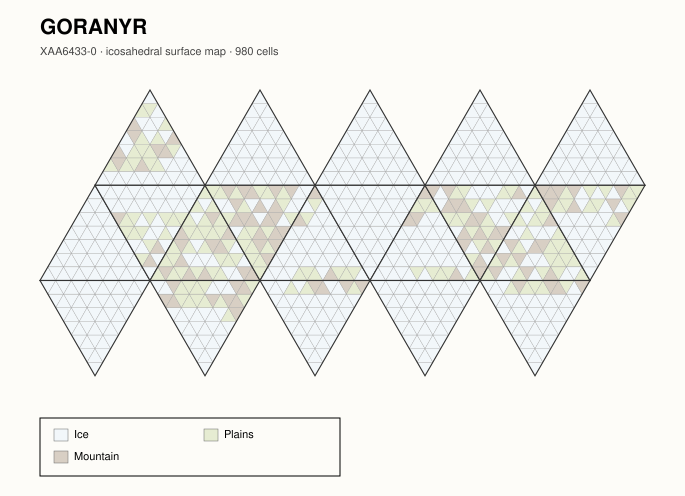

In [10]:
from IPython.display import SVG, display

terrain = wm.generate_world_terrain(mw)
print("Terrain coverage:", wm.terrain_summary(terrain))
display(SVG(wm.render_world_map_svg(mw, terrain)))